### 📚 Lab Task 2: Cleaning Up the Mess

You’ll be working with a dataset of real student grades — 7 assignments and a final exam — but things aren’t as clean as they should be. Some values are missing, some are way off, and it’s your job to fix it.

You’ll explore the data, figure out what went wrong, and try different strategies to clean it up.

Get ready to:
- Spot broken data
- Try out different fixes
- Compare models
- Justify your decisions

### Dataset Introduction

The dataset comes from real student grades in a course at SFU. Students completed **7 assignments**, and we also have their **final exam grade**.

It’s your job to explore the dataset and clean it up.

---

> 💡 **Note**: Students could receive bonus marks for some assignments:
> - **A2**: up to **15** points
> - **A4**: up to **5** points
> - **A6**: up to **10** points  
> Keep this in mind when you're evaluating high or unusual scores — they might not be errors!


**Attention:** The bonus values are in **points** not **percentages**!!!
---

### ✅ What You Need to Do

-  **Explore the dataset**
  - Look at basic stats, column names, and what the data looks like
  - Identify anything that stands out right away

-  **Check the correlations**
  - Use a correlation matrix to find relationships between assignments and the final exam
  - Do any assignments seem strongly related to final exam performance?

-  **If you could only use two assignment grades to predict the final exam**, which ones would you choose — and why?

-  **Check for missing values**
  - Which columns have them?
  - How many are missing?

-  **Handle the missing values**
  - Try out different imputation strategies (mean, median, remove, etc.)
  - Which one gives you the best results? Why do you think that is?
  - Exploration idea: search and see what are the ways of evaluating your results. How can you make sure that a strategy for handling the missing values works better than the other?

-  **Check for outliers**
  - Identify values that seem unrealistic or suspicious
  - Decide whether to keep, modify, or remove them — and explain your reasoning
  - Compare the results

---

For each step, be ready to explain your decisions. There isn’t always one "right" answer — we’re more interested in your reasoning!

> 💡 **Note**: If handling missing values and outliers for **all 7 assignments** feels overwhelming, it’s totally fine to **focus on just the two columns you think are most important**.  
> Just make sure your reasoning for choosing them is solid and clearly explained.


# Completed Lab Task 2

In this lab task, I use both provided datasets:

1. `grades_crpt.csv`, which contains assignment grades and final exam grades.
2. `student_health_data_m.csv`, which contains student health and lifestyle information.

The grade dataset is still the main dataset for the lab because the main task is about cleaning grades and predicting the final exam. I also use the health dataset by connecting it to the grade dataset through `user_id`. This lets me check whether health-related variables add useful information after the grade data has been cleaned.

## 1. Import libraries and load the two datasets

I start by importing the basic libraries I need. I use Pandas for working with tables, NumPy for numerical calculations, and Matplotlib for simple visual checks.

Then I load both datasets. I keep the original datasets unchanged at first because I want to inspect the problems before changing anything.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

grades_df = pd.read_csv("grades_crpt.csv")
health_df = pd.read_csv("student_health_data_m.csv")

print("Grades dataset shape:", grades_df.shape)
print("Health dataset shape:", health_df.shape)

Grades dataset shape: (86, 9)
Health dataset shape: (100, 9)


## 2. First look at the data

Before I clean anything, I want to understand what the data looks like. This is important because cleaning should not be random. I need evidence first.

For both datasets, I check:

- the first few rows,
- the column names,
- the data types,
- the basic statistics,
- and the number of missing values.

This gives me a starting point for deciding what problems need to be fixed.

In [2]:
print("Grades columns:")
print(grades_df.columns.tolist())

display(grades_df.head())

Grades columns:
['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'Final_Exam', 'user_id']


,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,NaN,NaN,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,NaN,NaN,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,NaN,86.2,100.0,NaN,NaN,67.8,U003
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
4,0.0,NaN,0.0,0.0,NaN,NaN,NaN,0.0,U005


In [3]:
print("Health columns:")
print(health_df.columns.tolist())

display(health_df.head())

Health columns:
['user_id', 'gender', 'age', 'unit_system', 'height', 'weight', 'steps_per_day', 'BMI', 'sleep_hours']


,user_id,gender,age,unit_system,height,weight,steps_per_day,BMI,sleep_hours
0,U003,Male,29.0,Metric,178.9,80.2,6483.0,25.1,6.0
1,U005,Male,27.0,Metric,162.8,64.3,NaN,24.3,5.5
2,U006,Female,21.0,Metric,NaN,73.8,4286.0,26.4,4.0
3,U008,Male,NaN,Metric,176.2,87.0,5420.0,28.0,5.1
4,U009,Male,29.0,Metric,182.5,76.5,9121.0,23.0,7.5


In [4]:
print("Grades information:")
grades_df.info()

Grades information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   A1          57 non-null     float64
 1   A2          61 non-null     float64
 2   A3          62 non-null     float64
 3   A4          77 non-null     float64
 4   A5          61 non-null     float64
 5   A6          67 non-null     float64
 6   A7          76 non-null     float64
 7   Final_Exam  86 non-null     float64
 8   user_id     86 non-null     object 
dtypes: float64(8), object(1)
memory usage: 6.2+ KB


In [5]:
print("Health information:")
health_df.info()

Health information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   user_id        100 non-null    object 
 1   gender         91 non-null     object 
 2   age            86 non-null     float64
 3   unit_system    100 non-null    object 
 4   height         83 non-null     float64
 5   weight         95 non-null     float64
 6   steps_per_day  95 non-null     float64
 7   BMI            87 non-null     float64
 8   sleep_hours    100 non-null    float64
dtypes: float64(6), object(3)
memory usage: 7.2+ KB


In [9]:
print("Basic statistics for grades:")
display(grades_df.describe())

print("Missing values in grades:")
display(grades_df.isna().sum())

Basic statistics for grades:


,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,57.000000,61.000000,62.000000,77.000000,61.000000,67.000000,76.000000,86.000000
mean,83.671930,81.096721,68.174194,82.332468,89.645902,74.437313,78.130263,55.509302
std,34.286481,28.556721,42.343621,39.101984,25.510505,31.176535,26.412058,18.176777
min,-4.500000,-30.600000,-70.100000,-21.600000,7.700000,-17.000000,0.000000,0.000000
25%,75.800000,64.300000,50.000000,72.000000,87.000000,60.000000,70.300000,45.850000
50%,87.500000,91.100000,80.000000,87.500000,95.000000,80.000000,80.000000,56.050000
75%,95.800000,100.000000,93.250000,95.000000,100.000000,92.500000,87.500000,67.725000
max,174.600000,148.900000,152.200000,188.200000,173.900000,183.600000,150.600000,97.500000


Missing values in grades:


,0
A1,29
A2,25
A3,24
A4,9
A5,25
A6,19
A7,10
Final_Exam,0
user_id,0


In [10]:
print("Basic statistics for health data:")
display(health_df.describe())

print("Missing values in health data:")
display(health_df.isna().sum())

Basic statistics for health data:


,age,height,weight,steps_per_day,BMI,sleep_hours
count,86.000000,83.000000,95.000000,95.000000,87.000000,100.000000
mean,24.162791,124.371084,118.664211,6174.852632,24.548276,5.847000
std,3.524237,53.824406,54.082878,3947.159488,5.700466,1.274732
min,18.000000,58.000000,48.600000,501.000000,3.300000,3.000000
25%,21.000000,66.100000,68.500000,4243.000000,22.350000,5.000000
50%,25.000000,158.200000,91.100000,5520.000000,24.500000,5.800000
75%,27.000000,171.650000,166.850000,7604.500000,27.400000,6.800000
max,29.000000,225.000000,253.400000,30000.000000,36.800000,9.500000


Missing values in health data:


,0
user_id,0
gender,9
age,14
unit_system,0
height,17
weight,5
steps_per_day,5
BMI,13
sleep_hours,0


### What I notice from the first inspection

From the first inspection, I notice several important problems.

First, the grade dataset has missing values in many assignment columns. The final exam column does not have missing values, so I can still use it as the target for prediction.

Second, some grade values are clearly suspicious. For example, some assignment grades are negative, and some are far above the normal maximum. The lab instructions say that some assignments had bonus points, so I cannot simply treat every value above 100 as wrong. I need to use the correct maximum for each assignment.

Third, the health dataset has a `unit_system` column. This means some height and weight values are in metric units and some are in US units. I should not compare those values directly until I convert them into the same unit system.

## 3. Connect the two datasets using `user_id`

Both datasets have a `user_id` column. I use this column to connect the grade data and the health data.

Before merging, I check how many grade students also appear in the health dataset. This matters because if many students did not match, the health dataset would be less useful for this lab.

In [11]:
matching_ids = grades_df["user_id"].isin(health_df["user_id"]).sum()

print("Number of students in grades dataset:", len(grades_df))
print("Number of students in health dataset:", len(health_df))
print("Number of grade students found in the health dataset:", matching_ids)

Number of students in grades dataset: 86
Number of students in health dataset: 100
Number of grade students found in the health dataset: 86


In [12]:
merged_raw_df = pd.merge(grades_df, health_df, on="user_id", how="left")

print("Merged dataset shape:", merged_raw_df.shape)
display(merged_raw_df.head())

Merged dataset shape: (86, 17)


,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id,gender,age,unit_system,height,weight,steps_per_day,BMI,sleep_hours
0,NaN,NaN,30.0,75.0,90.0,65.0,50.6,68.8,U001,Male,19.0,US,61.6,171.6,900.0,31.8,4.0
1,100.0,NaN,NaN,92.5,100.0,100.0,84.4,50.3,U002,Female,27.0,US,63.3,157.5,3942.0,27.6,4.8
2,75.0,69.6,NaN,86.2,100.0,NaN,NaN,67.8,U003,Male,29.0,Metric,178.9,80.2,6483.0,25.1,6.0
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004,Male,NaN,US,NaN,153.6,9366.0,NaN,7.0
4,0.0,NaN,0.0,0.0,NaN,NaN,NaN,0.0,U005,Male,27.0,Metric,162.8,64.3,NaN,24.3,5.5


The merge keeps all students from the grade dataset because the grade dataset is the main dataset for the lab. The health columns are added beside the grade columns.

This merged dataset is useful, but I do not use it for final analysis yet. I still need to clean the grade values and standardize the health values first.

## 4. Clean the health dataset first

I clean the health dataset before using it in the merged data.

The main issue is unit consistency. The `height` and `weight` columns use different units depending on the `unit_system` value:

- If `unit_system` is `Metric`, I treat height as centimeters and weight as kilograms.
- If `unit_system` is `US`, I convert height from inches to centimeters and weight from pounds to kilograms.

This is necessary because a value like `70` means very different things depending on the unit. It could mean 70 centimeters, 70 inches, or 70 kilograms depending on the column and unit system. If I do not convert the units, correlations and models using health data would be misleading.

In [13]:
health_clean = health_df.copy()

health_clean["height_cm"] = health_clean["height"]
health_clean["weight_kg"] = health_clean["weight"]

us_mask = health_clean["unit_system"] == "US"

health_clean.loc[us_mask, "height_cm"] = health_clean.loc[us_mask, "height"] * 2.54
health_clean.loc[us_mask, "weight_kg"] = health_clean.loc[us_mask, "weight"] * 0.453592

display(health_clean[["user_id", "unit_system", "height", "height_cm", "weight", "weight_kg"]].head(10))

,user_id,unit_system,height,height_cm,weight,weight_kg
0,U003,Metric,178.9,178.9,80.2,80.2
1,U005,Metric,162.8,162.8,64.3,64.3
2,U006,Metric,NaN,NaN,73.8,73.8
3,U008,Metric,176.2,176.2,87.0,87.0
4,U009,Metric,182.5,182.5,76.5,76.5
5,U010,Metric,170.7,170.7,68.7,68.7
6,U011,Metric,181.7,181.7,91.1,91.1
7,U013,Metric,172.1,172.1,78.0,78.0
8,U015,Metric,159.7,159.7,59.5,59.5
9,U016,Metric,NaN,NaN,79.6,79.6


After converting the units, I check for unrealistic health values. I do not want to delete whole rows immediately because one bad health value does not mean the student's grade data is useless.

Instead, I replace only the suspicious health values with missing values (`NaN`). This keeps the rest of each row available.

For this health data, I use simple realistic ranges:

- height in centimeters should be between 120 and 220,
- weight in kilograms should be between 35 and 200,
- BMI should be between 12 and 60,
- steps per day should be between 0 and 25,000,
- sleep hours should be between 0 and 14.

These ranges are not perfect medical rules. They are practical data-cleaning boundaries for finding values that are probably entry errors or processing problems.

In [14]:
health_rules = {
    "height_cm": (120, 220),
    "weight_kg": (35, 200),
    "BMI": (12, 60),
    "steps_per_day": (0, 25000),
    "sleep_hours": (0, 14)
}

health_outlier_summary = []

for col, limits in health_rules.items():
    low = limits[0]
    high = limits[1]
    bad_mask = (health_clean[col] < low) | (health_clean[col] > high)

    health_outlier_summary.append({
        "column": col,
        "low_limit": low,
        "high_limit": high,
        "suspicious_values": bad_mask.sum()
    })

    health_clean.loc[bad_mask, col] = np.nan

health_outlier_summary_df = pd.DataFrame(health_outlier_summary)
display(health_outlier_summary_df)

print("Missing values after health cleaning:")
display(health_clean[["gender", "age", "height_cm", "weight_kg", "steps_per_day", "BMI", "sleep_hours"]].isna().sum())

,column,low_limit,high_limit,suspicious_values
0,height_cm,120,220,3
1,weight_kg,35,200,0
2,BMI,12,60,3
3,steps_per_day,0,25000,1
4,sleep_hours,0,14,0


Missing values after health cleaning:


,0
gender,9
age,14
height_cm,20
weight_kg,5
steps_per_day,6
BMI,16
sleep_hours,0


### My decision for the health data

I keep the health dataset, but I use it carefully. The health variables may or may not help predict the final exam. I should not assume they help just because they are available.

The most important cleaning decision here is that I standardize the units first. Without that step, the health data would mix inches with centimeters and pounds with kilograms, which would make the analysis unfair and confusing.

## 5. Check suspicious grade values

Now I clean the grade dataset.

The lab instructions say that some assignments could have bonus marks:

- A2 can go up to 115 because it has up to 15 bonus points.
- A4 can go up to 105 because it has up to 5 bonus points.
- A6 can go up to 110 because it has up to 10 bonus points.

This means I should not automatically remove every score above 100. I need to use the correct allowed range for each column.

For the other assignments and the final exam, I use 0 to 100 as the allowed range.

In [15]:
grade_rules = {
    "A1": (0, 100),
    "A2": (0, 115),
    "A3": (0, 100),
    "A4": (0, 105),
    "A5": (0, 100),
    "A6": (0, 110),
    "A7": (0, 100),
    "Final_Exam": (0, 100)
}

grade_outlier_summary = []

for col, limits in grade_rules.items():
    low = limits[0]
    high = limits[1]
    bad_mask = (grades_df[col] < low) | (grades_df[col] > high)
    bad_values = grades_df.loc[bad_mask, col]

    grade_outlier_summary.append({
        "column": col,
        "low_limit": low,
        "high_limit": high,
        "suspicious_values": bad_mask.sum(),
        "smallest_suspicious_value": bad_values.min() if len(bad_values) > 0 else np.nan,
        "largest_suspicious_value": bad_values.max() if len(bad_values) > 0 else np.nan
    })

grade_outlier_summary_df = pd.DataFrame(grade_outlier_summary)
display(grade_outlier_summary_df)

,column,low_limit,high_limit,suspicious_values,smallest_suspicious_value,largest_suspicious_value
0,A1,0,100,6,-4.5,174.6
1,A2,0,115,2,-30.6,148.9
2,A3,0,100,7,-70.1,152.2
3,A4,0,105,7,-21.6,188.2
4,A5,0,100,5,131.4,173.9
5,A6,0,110,3,-17.0,183.6
6,A7,0,100,7,110.3,150.6
7,Final_Exam,0,100,0,NaN,NaN


The suspicious grade values are not all the same type of problem. Some values are negative, which cannot be real grades. Some values are much higher than the allowed maximum, even after considering bonus marks.

My decision is to replace these suspicious grade values with `NaN` instead of deleting the whole row. I do this because the student may still have useful scores in other columns. Replacing only the bad value is more careful than removing the entire student record.

In [16]:
grades_clean = grades_df.copy()

for col, limits in grade_rules.items():
    low = limits[0]
    high = limits[1]
    bad_mask = (grades_clean[col] < low) | (grades_clean[col] > high)
    grades_clean.loc[bad_mask, col] = np.nan

print("Missing values before cleaning suspicious grades:")
display(grades_df.isna().sum())

print("Missing values after changing suspicious grades to NaN:")
display(grades_clean.isna().sum())

display(grades_clean.head())

Missing values before cleaning suspicious grades:


,0
A1,29
A2,25
A3,24
A4,9
A5,25
A6,19
A7,10
Final_Exam,0
user_id,0


Missing values after changing suspicious grades to NaN:


,0
A1,35
A2,27
A3,31
A4,16
A5,30
A6,22
A7,17
Final_Exam,0
user_id,0


,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,NaN,NaN,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,NaN,NaN,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,NaN,86.2,100.0,NaN,NaN,67.8,U003
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
4,0.0,NaN,0.0,0.0,NaN,NaN,NaN,0.0,U005


## 6. Merge the cleaned grade and health datasets

Now I merge the cleaned grade data with the cleaned health data.

I keep the cleaned health columns that are easiest to interpret:

- gender,
- age,
- height in centimeters,
- weight in kilograms,
- steps per day,
- BMI,
- sleep hours.

This creates one cleaned working dataset.

In [17]:
health_columns_to_keep = [
    "user_id", "gender", "age", "unit_system",
    "height_cm", "weight_kg", "steps_per_day", "BMI", "sleep_hours"
]

merged_clean_df = pd.merge(
    grades_clean,
    health_clean[health_columns_to_keep],
    on="user_id",
    how="left"
)

print("Cleaned merged dataset shape:", merged_clean_df.shape)
display(merged_clean_df.head())

print("Missing values in cleaned merged dataset:")
display(merged_clean_df.isna().sum())

Cleaned merged dataset shape: (86, 17)


,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id,gender,age,unit_system,height_cm,weight_kg,steps_per_day,BMI,sleep_hours
0,NaN,NaN,30.0,75.0,90.0,65.0,50.6,68.8,U001,Male,19.0,US,156.464,77.836387,900.0,31.8,4.0
1,100.0,NaN,NaN,92.5,100.0,100.0,84.4,50.3,U002,Female,27.0,US,160.782,71.440740,3942.0,27.6,4.8
2,75.0,69.6,NaN,86.2,100.0,NaN,NaN,67.8,U003,Male,29.0,Metric,178.900,80.200000,6483.0,25.1,6.0
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004,Male,NaN,US,NaN,69.671731,9366.0,NaN,7.0
4,0.0,NaN,0.0,0.0,NaN,NaN,NaN,0.0,U005,Male,27.0,Metric,162.800,64.300000,NaN,24.3,5.5


Missing values in cleaned merged dataset:


,0
A1,35
A2,27
A3,31
A4,16
A5,30
A6,22
A7,17
Final_Exam,0
user_id,0
gender,8


## 7. Correlation analysis

Next, I check correlations with the final exam.

Correlation helps me understand which variables move together. A higher positive correlation with `Final_Exam` means that students with higher values in that column also tend to have higher final exam scores.

I check correlations after cleaning suspicious grade values because outliers can distort correlations. I also compare the raw and cleaned grade correlations so I can see how much the cleaning changed the relationships.

In [18]:
assignment_cols = ["A1", "A2", "A3", "A4", "A5", "A6", "A7"]

raw_corr = grades_df[assignment_cols + ["Final_Exam"]].corr()["Final_Exam"].drop("Final_Exam")
clean_corr = grades_clean[assignment_cols + ["Final_Exam"]].corr()["Final_Exam"].drop("Final_Exam")

corr_comparison_df = pd.DataFrame({
    "raw_correlation_with_final": raw_corr,
    "cleaned_correlation_with_final": clean_corr
}).sort_values("cleaned_correlation_with_final", ascending=False)

display(corr_comparison_df)

,raw_correlation_with_final,cleaned_correlation_with_final
A4,0.403466,0.534266
A1,0.212839,0.430238
A3,0.277859,0.336443
A2,0.284525,0.324228
A6,0.246127,0.313679
A7,0.380756,0.295414
A5,0.018271,0.140932


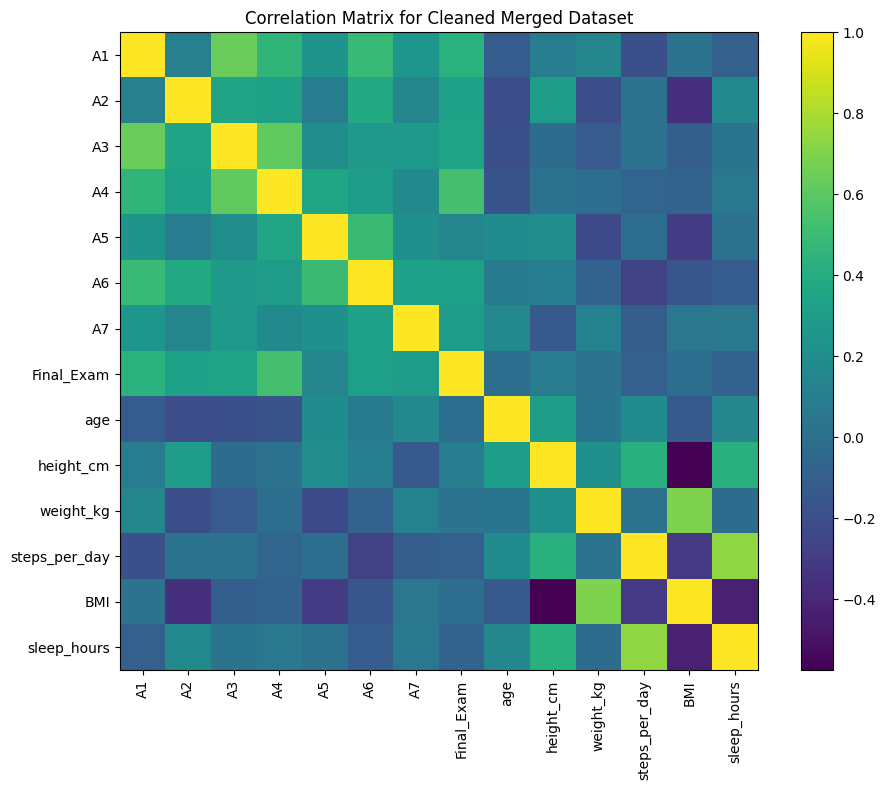

In [19]:
clean_corr_matrix = merged_clean_df.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 8))
plt.imshow(clean_corr_matrix)
plt.colorbar()
plt.xticks(range(len(clean_corr_matrix.columns)), clean_corr_matrix.columns, rotation=90)
plt.yticks(range(len(clean_corr_matrix.columns)), clean_corr_matrix.columns)
plt.title("Correlation Matrix for Cleaned Merged Dataset")
plt.tight_layout()
plt.show()

In [20]:
final_corr_all = merged_clean_df.select_dtypes(include="number").corr()["Final_Exam"].sort_values(ascending=False)
display(final_corr_all)

,Final_Exam
Final_Exam,1.000000
A4,0.534266
A1,0.430238
A3,0.336443
A2,0.324228
A6,0.313679
A7,0.295414
A5,0.140932
height_cm,0.086377
weight_kg,0.023221


### What I learn from the correlations

The cleaned assignment correlations show that assignment grades are more related to the final exam than the health variables are.

The health variables have weak correlations with the final exam in this dataset. This does not mean health is never important. It only means that, in this small dataset, the health columns do not show a strong direct relationship with final exam scores.

Among the assignments, A4 has the strongest cleaned correlation with the final exam. A1, A3, A2, A6, and A7 also have positive relationships, but the strength is different for each one. A5 has the weakest relationship with the final exam.

## 8. Build simple evaluation functions

To compare cleaning choices, I need a consistent evaluation method.

I use a simple linear prediction model built with NumPy. I do not use it because I think it is the perfect model. I use it because it gives me a fair way to compare different choices.

The evaluation steps are:

1. Choose the columns I want to use as predictors.
2. Handle missing values using one strategy.
3. Split the data into a training set and a testing set.
4. Fit a simple linear model on the training set.
5. Predict final exam scores for the testing set.
6. Compare predictions to the real final exam scores.

I use two error measurements:

- MAE: the average absolute error. Lower is better.
- RMSE: the square root of the average squared error. Lower is better, and it punishes large errors more strongly.

In [21]:
def prepare_model_data(df, features, target, strategy):
    data = df[features + [target]].copy()

    if strategy == "drop rows":
        data = data.dropna()

    elif strategy == "mean":
        for col in features:
            data[col] = data[col].fillna(data[col].mean())

    elif strategy == "median":
        for col in features:
            data[col] = data[col].fillna(data[col].median())

    elif strategy == "zero":
        for col in features:
            data[col] = data[col].fillna(0)

    else:
        raise ValueError("Unknown strategy")

    data = data.dropna()
    return data


def fit_linear_model(X, y):
    X_with_intercept = np.column_stack([np.ones(len(X)), X])
    coefficients = np.linalg.lstsq(X_with_intercept, y, rcond=None)[0]
    return coefficients


def predict_linear_model(X, coefficients):
    X_with_intercept = np.column_stack([np.ones(len(X)), X])
    predictions = X_with_intercept @ coefficients
    return predictions


def evaluate_model(df, features, target="Final_Exam", strategy="mean", random_state=42):
    data = prepare_model_data(df, features, target, strategy)

    train_data = data.sample(frac=0.7, random_state=random_state)
    test_data = data.drop(train_data.index)

    X_train = train_data[features].values
    y_train = train_data[target].values

    X_test = test_data[features].values
    y_test = test_data[target].values

    coefficients = fit_linear_model(X_train, y_train)
    predictions = predict_linear_model(X_test, coefficients)

    mae = np.mean(np.abs(y_test - predictions))
    rmse = np.sqrt(np.mean((y_test - predictions) ** 2))

    return {
        "features": " + ".join(features),
        "strategy": strategy,
        "rows_used": len(data),
        "train_rows": len(train_data),
        "test_rows": len(test_data),
        "MAE": mae,
        "RMSE": rmse
    }

## 9. Choose the best two assignment columns

The lab asks which two assignment grades I would use to predict the final exam.

I first use correlation to find strong individual candidates. However, the best two individual columns are not always the best pair. Two columns can overlap in the information they provide. Because of that, I also test every possible pair of assignment columns using the same evaluation method.

For this pair comparison, I use median imputation as a basic starting strategy. I choose median here because it is resistant to unusual values, and I already changed the most suspicious outliers into missing values.

In [22]:
pair_results = []

for col1, col2 in combinations(assignment_cols, 2):
    result = evaluate_model(
        merged_clean_df,
        features=[col1, col2],
        target="Final_Exam",
        strategy="median",
        random_state=42
    )
    pair_results.append(result)

pair_results_df = pd.DataFrame(pair_results).sort_values("RMSE")
display(pair_results_df.head(10))

,features,strategy,rows_used,train_rows,test_rows,MAE,RMSE
7,A2 + A4,median,86,60,26,13.420090,16.012164
17,A4 + A7,median,86,60,26,13.437245,16.020784
16,A4 + A6,median,86,60,26,13.881975,16.058219
2,A1 + A4,median,86,60,26,13.424340,16.088479
10,A2 + A7,median,86,60,26,13.536766,16.199533
0,A1 + A2,median,86,60,26,13.912146,16.557272
5,A1 + A7,median,86,60,26,14.521468,16.728558
11,A3 + A4,median,86,60,26,14.212176,16.890544
9,A2 + A6,median,86,60,26,14.268435,16.907619
4,A1 + A6,median,86,60,26,14.699007,16.966836


### My choice: A2 and A4

I choose A2 and A4 as the two assignment grades I would use to predict the final exam.

My reasoning is:

1. A4 has the strongest cleaned correlation with the final exam, so it is clearly important.
2. A2 and A4 give the best result in the pair comparison table when I use RMSE.
3. A1 is also a strong individual candidate, but it has many missing values after cleaning. It is very close to A2 and A4 in model performance, but A2 and A4 performs slightly better in this test.
4. A5 is not a good choice because it has a weak relationship with the final exam.

So I do not choose A2 and A4 only because they are convenient. I choose them because the correlation check and the pair model comparison both support that choice.

## 10. Compare missing-value strategies

Now I compare different strategies for handling missing values using the chosen assignment pair: A2 and A4.

I compare four strategies:

1. Drop rows with missing values.
2. Fill missing values with the mean.
3. Fill missing values with the median.
4. Fill missing values with zero.

I expect dropping rows to lose information because the dataset is small. I also expect zero filling to be risky because a missing value does not always mean the student earned zero. Mean and median are more reasonable because they keep all rows while using typical values from the column.

In [23]:
selected_features = ["A2", "A4"]

missing_strategy_results = []

for strategy in ["drop rows", "mean", "median", "zero"]:
    result = evaluate_model(
        merged_clean_df,
        features=selected_features,
        target="Final_Exam",
        strategy=strategy,
        random_state=42
    )
    missing_strategy_results.append(result)

missing_strategy_results_df = pd.DataFrame(missing_strategy_results).sort_values("RMSE")
display(missing_strategy_results_df)

,features,strategy,rows_used,train_rows,test_rows,MAE,RMSE
1,A2 + A4,mean,86,60,26,13.346140,15.884068
2,A2 + A4,median,86,60,26,13.420090,16.012164
3,A2 + A4,zero,86,60,26,14.266375,17.129610
0,A2 + A4,drop rows,50,35,15,16.493141,19.922553


### My decision for missing values

For the chosen A2 and A4 model, mean imputation gives the lowest RMSE and MAE in this comparison.

This makes sense for this dataset because I already changed impossible grade values into missing values. After that cleaning step, the remaining valid grades are less extreme. Because the extreme errors have already been removed, the mean becomes a reasonable estimate for missing assignment scores.

I do not choose the zero strategy because it creates artificial low grades. A missing assignment grade does not always mean the student got zero. It might mean the data was not recorded correctly.

I also do not choose the drop-row strategy as my final method because it uses fewer rows. Since this dataset is not very large, dropping rows removes useful information and makes the evaluation less stable.

The median strategy is also reasonable and performs very close to mean imputation. However, based on the error comparison, I choose mean imputation for the final cleaned prediction dataset.

## 11. Check whether the health data improves prediction

Because I have a second dataset, I also test whether health variables improve the prediction.

I compare:

- A2 and A4 only,
- A2 and A4 plus sleep and steps,
- A2 and A4 plus BMI and sleep,
- health variables only,
- and A1 and A4 as a close grade-only comparison.

I use mean imputation here because it performed best for the selected A2 and A4 model.

In [24]:
health_model_tests = [
    ["A2", "A4"],
    ["A2", "A4", "sleep_hours", "steps_per_day"],
    ["A2", "A4", "BMI", "sleep_hours"],
    ["sleep_hours", "steps_per_day", "BMI"],
    ["A1", "A4"]
]

health_model_results = []

for features in health_model_tests:
    result = evaluate_model(
        merged_clean_df,
        features=features,
        target="Final_Exam",
        strategy="mean",
        random_state=42
    )
    health_model_results.append(result)

health_model_results_df = pd.DataFrame(health_model_results).sort_values("RMSE")
display(health_model_results_df)

,features,strategy,rows_used,train_rows,test_rows,MAE,RMSE
0,A2 + A4,mean,86,60,26,13.346140,15.884068
4,A1 + A4,mean,86,60,26,13.357259,15.897574
1,A2 + A4 + sleep_hours + steps_per_day,mean,86,60,26,14.651664,17.219556
2,A2 + A4 + BMI + sleep_hours,mean,86,60,26,14.802642,17.555667
3,sleep_hours + steps_per_day + BMI,mean,86,60,26,16.721346,20.287668


### What I decide about the health data

The health dataset is useful because it gives extra information about the students, and it also gives me another cleaning problem to solve. However, in this dataset, the health variables do not improve the final exam prediction.

The grade-only model using A2 and A4 performs better than the models that add health variables. The health-only model performs the worst. This tells me that, for this lab task, assignment performance is more useful for predicting final exam performance than the health variables.

I still include the health dataset because it helps me check whether extra variables add predictive value. The result is important even though the health variables do not improve the model. It shows that more data does not automatically mean better prediction.

## 12. Create the final cleaned working dataset

For the final cleaned working dataset, I keep:

- the cleaned grade values,
- the cleaned and standardized health values,
- and the selected assignment columns A2 and A4.

For missing assignment values, I create final imputed versions of A2 and A4 using mean imputation because that strategy performed best in the comparison.

In [25]:
final_df = merged_clean_df.copy()

for col in selected_features:
    final_df[col + "_imputed"] = final_df[col].fillna(final_df[col].mean())

display(final_df[[
    "user_id",
    "A2", "A2_imputed",
    "A4", "A4_imputed",
    "Final_Exam",
    "age", "height_cm", "weight_kg", "steps_per_day", "BMI", "sleep_hours"
]].head(15))

,user_id,A2,A2_imputed,A4,A4_imputed,Final_Exam,age,height_cm,weight_kg,steps_per_day,BMI,sleep_hours
0,U001,NaN,81.840678,75.0,75.000000,68.8,19.0,156.464,77.836387,900.0,31.8,4.0
1,U002,NaN,81.840678,92.5,92.500000,50.3,27.0,160.782,71.440740,3942.0,27.6,4.8
2,U003,69.6,69.600000,86.2,86.200000,67.8,29.0,178.900,80.200000,6483.0,25.1,6.0
3,U004,78.6,78.600000,0.0,0.000000,0.0,NaN,NaN,69.671731,9366.0,NaN,7.0
4,U005,NaN,81.840678,0.0,0.000000,0.0,27.0,162.800,64.300000,NaN,24.3,5.5
5,U006,92.9,92.900000,96.2,96.200000,97.5,21.0,NaN,73.800000,4286.0,26.4,4.0
6,U007,64.3,64.300000,NaN,75.977143,64.4,25.0,NaN,93.530670,3836.0,NaN,5.0
7,U008,100.0,100.000000,95.0,95.000000,40.6,NaN,176.200,87.000000,5420.0,28.0,5.1
8,U009,85.7,85.700000,90.0,90.000000,51.9,29.0,182.500,76.500000,9121.0,23.0,7.5
9,U010,76.8,76.800000,93.8,93.800000,65.3,26.0,170.700,68.700000,7474.0,23.6,6.5


In [26]:
print("Final selected columns for prediction:")
print(selected_features)

print("\nMean values used for final imputation:")
for col in selected_features:
    print(col, "mean =", final_df[col].mean())

print("\nFinal missing values in selected imputed columns:")
display(final_df[["A2_imputed", "A4_imputed"]].isna().sum())

Final selected columns for prediction:
['A2', 'A4']

Mean values used for final imputation:
A2 mean = 81.84067796610168
A4 mean = 75.97714285714285

Final missing values in selected imputed columns:


,0
A2_imputed,0
A4_imputed,0


## 13. Final conclusion

My final answer is that I would use A2 and A4 to predict the final exam.

I made this decision through several steps.

First, I inspected both datasets to understand their structure, missing values, and possible errors. I used the grade dataset as the main dataset because the task is about assignment grades and final exam prediction. I also used the health dataset by joining it with the grade dataset through `user_id`.

Second, I cleaned the health data by converting US measurements into metric measurements. This was necessary because raw height and weight values from different unit systems cannot be compared fairly. I also changed unrealistic health values into missing values instead of deleting whole rows.

Third, I cleaned the grade data using assignment-specific limits. I did not treat all values above 100 as errors because A2, A4, and A6 had bonus points. After applying the correct limits, I changed impossible values into missing values.

Fourth, I checked correlations with the final exam. A4 had the strongest cleaned relationship with the final exam. A1 was also strong, but it had more missing values after cleaning.

Fifth, I compared all pairs of assignment columns using a simple linear model. A2 and A4 gave the best result by RMSE in the pair comparison, so I chose them as my final two assignment predictors.

Sixth, I compared missing-value strategies. Mean imputation worked best for A2 and A4 in this test. Median imputation was also close, but dropping rows removed too much data and zero filling created unrealistic low values.

Finally, I tested whether the health variables improved prediction. They did not improve the simple model in this dataset. This does not mean health is never important, but it shows that, for this specific dataset and task, assignment grades are more useful predictors of final exam scores.
